### Import Libraries

In [19]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


### Load Preprocessed Dataset

In [3]:
df = pd.read_csv("ghg_preprocessed.csv")

df.head()

,Year,FlowAmount_Carbon dioxide,FlowAmount_Carbon tetrafluoride,FlowAmount_HFC-125,FlowAmount_HFC-134a,FlowAmount_HFC-143a,FlowAmount_HFC-23,FlowAmount_HFC-236fa,FlowAmount_HFC-32,"FlowAmount_HFCs and PFCs, unspecified",...,SectorName_Textile Mills,SectorName_Textile Product Mills,SectorName_Transit and Ground Passenger Transportation,SectorName_Truck Transportation,SectorName_Warehousing and Storage,SectorName_Waste Management and Remediation Services,SectorName_Water Transportation,"SectorName_Water, Sewage and Other Systems",SectorName_Wholesale Electronic Markets and Agents and Brokers,SectorName_Wood Product Manufacturing
0,2012,-0.152631,-0.041781,-0.134094,-0.133040,-0.135315,-0.016021,-0.124258,-0.126468,-0.136408,...,False,False,False,False,False,False,False,False,False,False
1,2013,-0.152336,-0.041781,-0.133741,-0.133558,-0.135051,-0.016021,-0.124366,-0.125933,-0.136412,...,False,False,False,False,False,False,False,False,False,False
2,2014,-0.152522,-0.041781,-0.133329,-0.133705,-0.134803,-0.016021,-0.124361,-0.125457,-0.136244,...,False,False,False,False,False,False,False,False,False,False
3,2015,-0.152076,-0.041781,-0.133030,-0.133927,-0.134710,-0.016021,-0.125101,-0.124945,-0.136157,...,False,False,False,False,False,False,False,False,False,False
4,2016,-0.153127,-0.041781,-0.132652,-0.134311,-0.134605,-0.016021,-0.125749,-0.124395,-0.136106,...,False,False,False,False,False,False,False,False,False,False


### Narrative:

The Random Forest Regression model was chosen for this project because of its robustness in handling high-dimensional, non-linear data with many features, including one-hot encoded categorical variables such as U.S. states and industrial sectors. The dataset included over 200 features derived from greenhouse gas (GHG) emission amounts by gas type, sector, and state over time.

The main question the prospective model would address is the following: To what extent can total greenhouse gas emissions be predicted based on key specific greenhouse gases, industrial sector, state, and year? 

Predicting total emissions based on key greenhouse gases, sector, state, and time is crucial in understanding the drivers behind national U.S. emission trends. Rather than relying on all available gases or the most impactful ones, this model focuses on gases that best serve as statistical proxies - offering strong predictive signals for overall emissions. By incorporating industrial and geographical (state-specific) information, the model addresses broader research goals related to how emissions may be impacted differently acrosss industries and regions over time. This targeted predictive framework supports investigation of consistnet multi-gas emissions profiles, highlights which states or sectors may be the highest/lowest contributors to emissions, and provide the foundation for identifying trends and potential intervention points without the requirement of gas monitoring across the full spectrum of greenhouse gases. 

### Feature Selection: 
Firstly, the greenhouse gases that are most indicative of total emissions will be investigated. Below is a horizontal bar chart ranking of cumulative greenhouse gas contribution to total emissions by the GWP amount per greenhouse gas:

C:\Users\viana\AppData\Local\Temp\ipykernel_25652\1840449506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_gwp_by_gas.values, y=total_gwp_by_gas.index, palette="viridis")


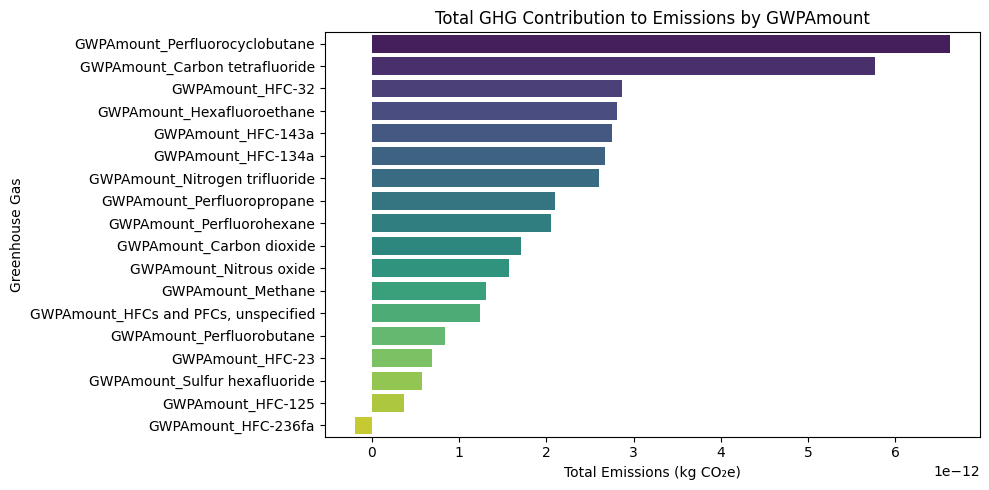

In [10]:
gwp_columns = [col for col in df.columns if "GWP" in col]

total_gwp_by_gas = df[gwp_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=total_gwp_by_gas.values, y=total_gwp_by_gas.index, palette="viridis")
plt.title("Total GHG Contribution to Emissions by GWPAmount")
plt.xlabel("Total Emissions (kg CO₂e)")
plt.ylabel("Greenhouse Gas")
plt.tight_layout()
plt.show()

The bar chart above displays Perfluorocyclobutane, Carbon tetrafluoride, and HFC-32 as the gases with the highest cumulative emissions. However, total contribution does not necessarily reflect how informative a gas may be as a predictor for total emissions.

Instead, a correlation matrix can be used to indicate how strongly each greenhouse gas correlates with the total emissions amount for each industrial sector, state, and year specific record. Below is a correlation matrix to show which specific greenhouse gas GWP amount correlate the most with TotalEmissions:

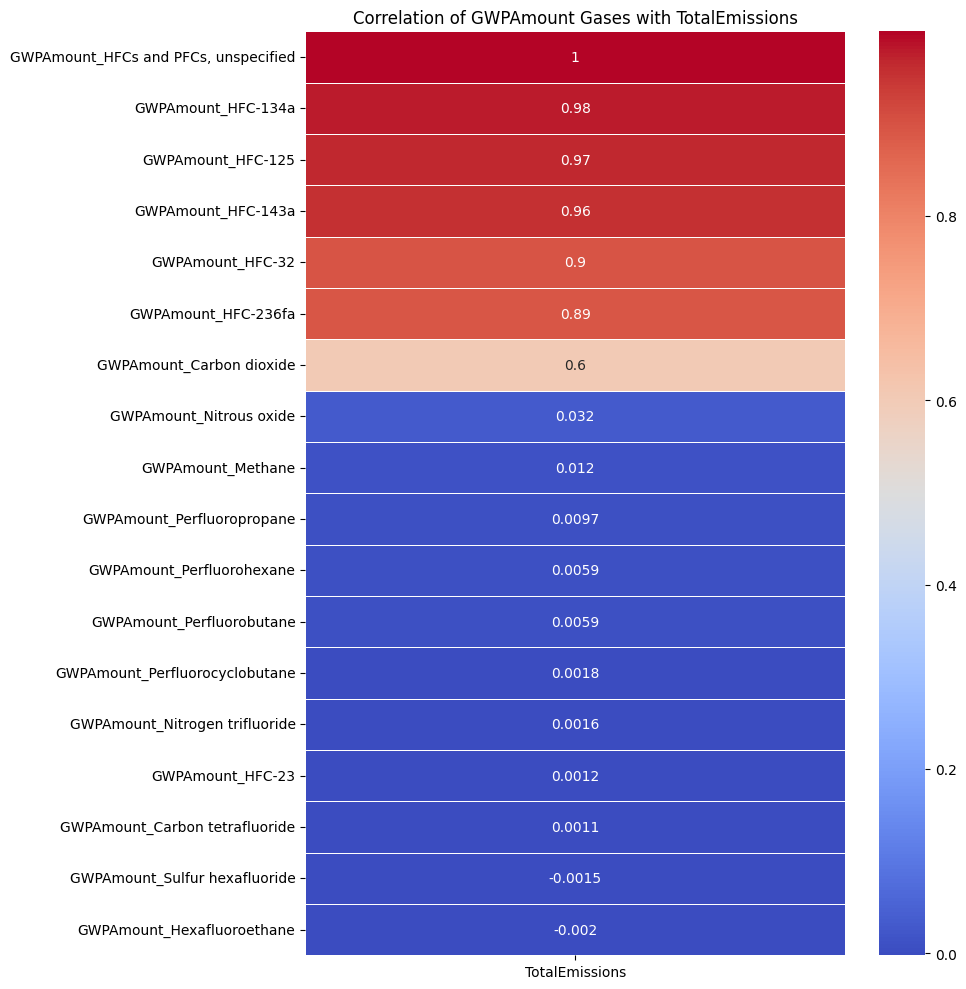

In [11]:
correlation_matrix = df[gwp_columns + ['TotalEmissions']].corr()

correlations_with_total = correlation_matrix[['TotalEmissions']].drop('TotalEmissions').sort_values(by='TotalEmissions', ascending=False)

plt.figure(figsize=(10, 10))
sns.heatmap(correlations_with_total, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of GWPAmount Gases with TotalEmissions")
plt.tight_layout()
plt.show()

The correlation matrix above shows that HFC-134a, HFC-125, and HFC-143a have extremely strong positive correlations with the total amount of greenhouse gas emissions (each above 0.95 based on the Pearson Correlation Coefficient). Unexpectedly, the highest contributing greenhouse gases Perfluorocyclobutane and Carbon tetrafluoride have little (almost no) correlation with total emissions, making the highest contributing greenhouse gases poor predictors (though HFC-32 has strong positive correlation and therefore may be a decent predictor of total emissions at 0.9 Pearson Correlation Coefficient). 

Unspecified HFCs and PFCs have a near-perfect correlation with total emissions (1 correlation coefficient), however this feature represents an aggregated mix of multiple undefined gases, which would decrease the explanatory power of this model. 

Therefore, the hydrofluorocarbons HFC-134a, HFC-125, and HFC-143a will be used as features in the regression model to predict total emissions. 

To figure out whether state, sector, and year are good predictors of total emissions independent of using greenhouse gas emissions values as predictors, a baseline random forest regression model can be built using the year, one-hot encoded state, and one-hot encoded sector values and its performance can be evaluated. A random forest model is well-suited for this case since it can handle high-dimensional categorical data without assuming a linear relationship, enabling a random forest model to capture complex interactions (unlike models such as linear regression). In addition the random forest model is robust against multicollinearity (which may exist within greenhouse gas emissions which will be added later) and noise. Below, the baseline model will be created:

Mean Absolute Error (MAE): 3,314,996,138.96
Root Mean Squared Error (RMSE): 12,882,335,951.92
R² Score: 0.9966


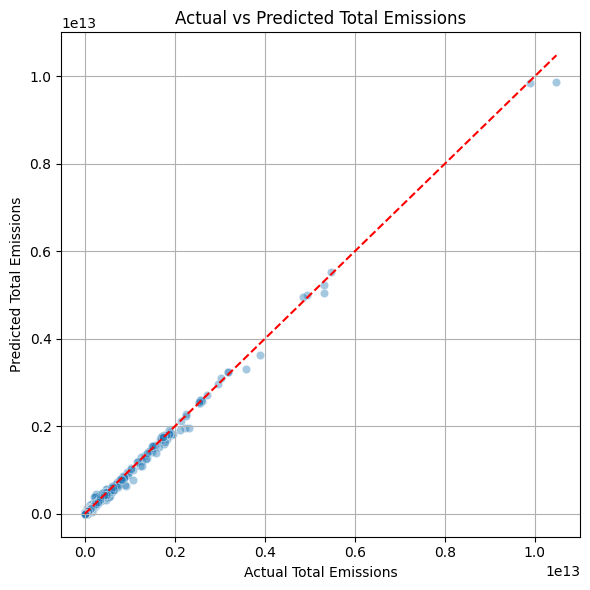

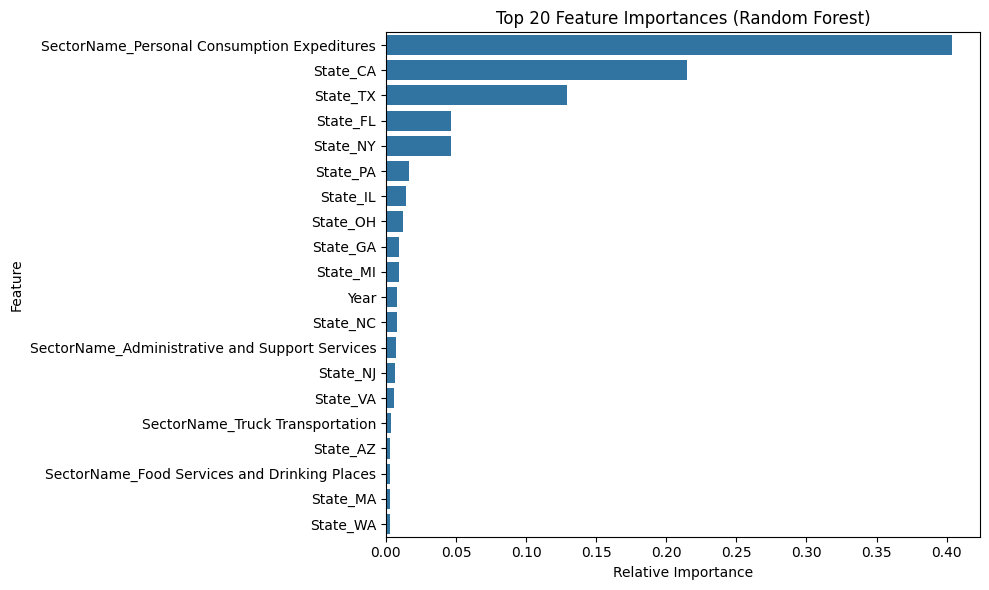

In [17]:
#Define the features and target
feature_cols = ['Year'] + [col for col in df.columns if col.startswith('SectorName_') or col.startswith('State_')]
X = df[feature_cols]
y = df["TotalEmissions"]

#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#Predict on test set
y_pred = rf_model.predict(X_test)

#Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

#Actual vs predicted plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title("Actual vs Predicted Total Emissions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.grid(True)
plt.show()

#Calculate feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df[:20], y=importance_df[:20].index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

From above, the model with `Year`, `Sector`, and `State` features alone performs exceptionally well with most points in the actual vs. prediction total emissions scatterplot to be closely clustered along the line of perfect prediction. The $R^2 = 0.9966$ shows that 99.66% of the variability in `TotalEmissions` can be explained by the model with `Year`, `Sector`, and `State`. The mean absolute error is at around 3 billion kg $CO_2e$ while the RMSE is at around 12 billion kg $CO_2e$.

### Train and Validate the Model:

Now, the model can be created with the addition of the HFC-134a, HFC-125, and HFC-143a GWP amounts as features:

Mean Absolute Error (MAE): 645,148,233.80
Root Mean Squared Error (RMSE): 8,058,619,000.95
R² Score: 0.9987


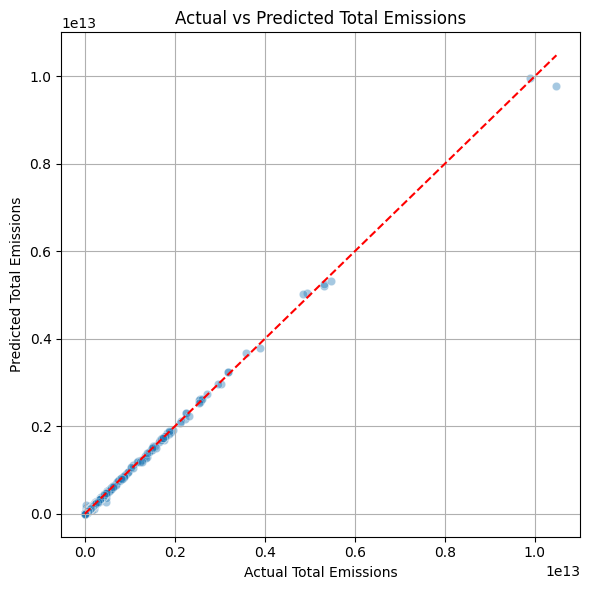

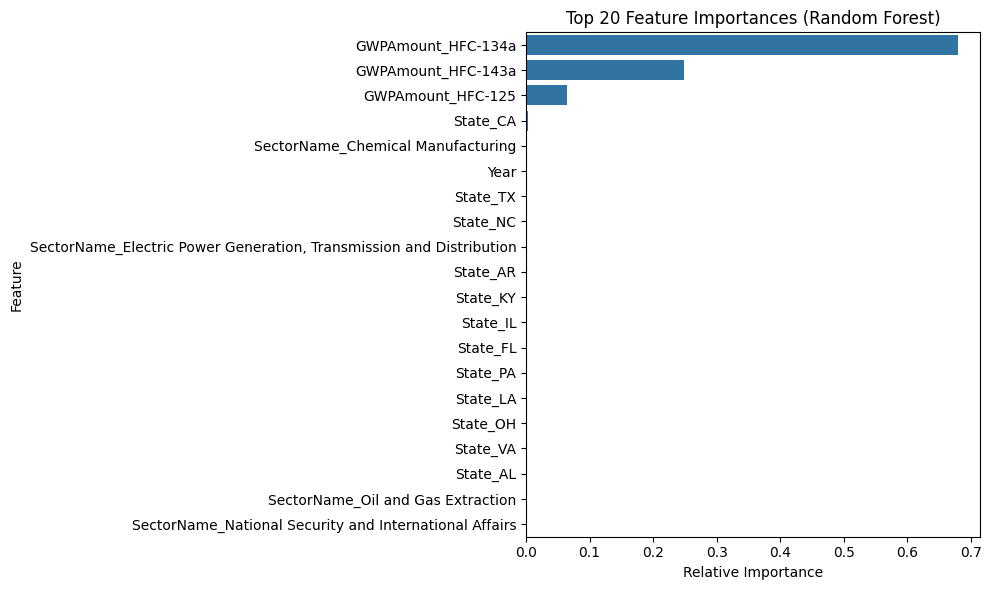

In [18]:
#Define the features and target
feature_cols =['GWPAmount_HFC-134a'] + ['GWPAmount_HFC-125'] + ['GWPAmount_HFC-143a'] + ['Year'] + [col for col in df.columns if col.startswith('SectorName_') or col.startswith('State_')]
X = df[feature_cols]
y = df["TotalEmissions"]

#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#Predict on test set
y_pred = rf_model.predict(X_test)

#Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

#Actual vs predicted plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title("Actual vs Predicted Total Emissions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.grid(True)
plt.show()

#Calculate feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df[:20], y=importance_df[:20].index)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation of Results:

The model achieved a very high R² score of 0.9987, indicating that it explains over 99.8% of the variance in total CO₂-equivalent emissions. The Mean Absolute Error (MAE) of ~645 million kg CO₂e and the Root Mean Squared Error (RMSE) of around 8 billion kg CO₂e further affirm the model’s strong predictive performance—especially when placed in context: the target variable (TotalEmissions) often ranges in the tens of billions of kilograms. These results demonstrate that total emissions can be reliably and accurately predicted using the detailed breakdowns of greenhouse gas types (FlowAmount, GWPAmount), sector activity, and state-level identifiers.

The Random Forest model identified that the calculated GWP (global warming potential) amounts of the 3 hydrofluorocarbons HFC-134a, HFC-143a, and HFC-125 are the most critical indicators of total CO₂-equivalent emissions, dominating the top feature importances. Additionally, state-level indicator `State_CA` and sector indicator `SectorName_Chemical Manufacturing` appear among the top 5 features ranked by feature importance (albeit at a much reduced level compared to the 3 hydrofluorocarbon features. The Year feature had very low importance, confirming that time is not as significant in explaining the variance of total emissions. 

Overall, this model directly addresses the research question by demonstrating that total emissions can be accurately inferred from a limited set of features, and confirms that emissions vary more meaningfully across certain sectors and states than over time.

### Cross-Validation

Cross-validation is valuable to perform since the dataset may have uneven representation across features such as sectors and states. Using multiple folds ensures that the model is tested on diverse combinations, and guards against overly optimistic results from a single train-test split. Therefore cross-validation will give a more robust measure of how well the model would generalize across a wide range of regional and industrial greenhouse gas emissions profiles. 

Below, a cross-validation using the Random Forest regression model will be performed with the `HFC-143a`, `HFC-125`, and `HFC-134a` GWP amount features along with the `Sector`, `State`, and `Year` features:

Mean Absolute Error (MAE): 749,987,775.03
Root Mean Squared Error (RMSE): 13,879,274,518.99
R² Score: 0.9967


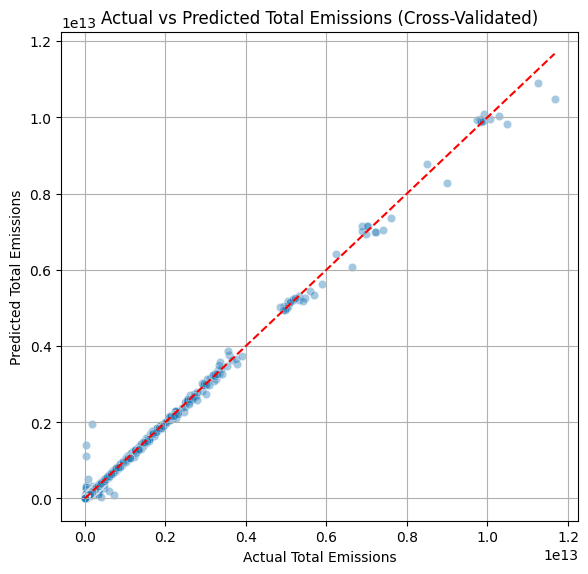

In [21]:
feature_cols =['GWPAmount_HFC-134a'] + ['GWPAmount_HFC-125'] + ['GWPAmount_HFC-143a'] + ['Year'] + [col for col in df.columns if col.startswith('SectorName_') or col.startswith('State_')]
X = df[feature_cols]
y = df["TotalEmissions"]

#Build Random Forest model and cross-validation
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
cross_validation = KFold(n_splits=5, shuffle=True, random_state=42)

#Perform cross-validation predictions
y_pred = cross_val_predict(rf_model, X, y, cv=cross_validation, n_jobs=-1)

#Evaluate model performance
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

#Actual vs predicted plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.4)
plt.xlabel("Actual Total Emissions")
plt.ylabel("Predicted Total Emissions")
plt.title("Actual vs Predicted Total Emissions (Cross-Validated)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Results

The cross-validated Random Forest regression model has achieved (similarly to before) an exceptionally high $R^2=0.9967$, which indicates that more than 99.6% of the variability of total emissions is explained with the model with a mean absolute error of ~750 million kg $CO_2e$ and a root mean squared error (RMSE) of ~13.9 billion kg $CO_2e$. Across all data folds, the model has consistent predictive accuracy (as evident by the clustering of points near the perfect prediction diagonal in the scatterplot of actual vs predicted total emissions). This directly supports that total greenhouse gas emissions can be accurately predicted using a select few hydrofluorocarbon indicator gases along with features such as sector, state, and year. The predictive success of this model therefore confirms a limited, interpretable set of features can reliably capture emissions behaviors across states and industries. 